# CAISO Data for 2024
This notebook analyzes CAISO production data for 2024, focusing on hourly and monthly averages of different energy sources.

Data is sourced from the CAISO website: [CAISO Production Data].  This spreadsheet contains production data for various energy sources including solar, wind, hydro, nuclear, and thermal (Natural Gas). [Production 2024](https://www.caiso.com/documents/production-and-curtailments-data-2024.xlsx)

```python


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Read in the data from Excel file, specifying the sheet name

In [5]:
# read production-and-curtailments-data-2024.xlsx
caiso=pd.read_excel("production-and-curtailments-data-2024.xlsx", sheet_name="Production")
caiso

,Date,Hour,Interval,Load,Solar,Wind,Net Load,Renewables,Nuclear,Large Hydro,Imports,Generation,Thermal,Load Less (Generation+Imports)
0,2024-01-01 00:00:00,1,1,21963.880208,0.0,312.191790,21651.688419,1803.613855,2240.800399,1790.351712,3511.653333,18442.999036,12608.233071,9.227839
1,2024-01-01 00:05:00,1,2,21790.949896,0.0,296.269300,21494.680596,1790.335010,2240.516000,1653.205104,3354.560000,18424.723073,12740.666959,11.666823
2,2024-01-01 00:10:00,1,3,21682.925833,0.0,295.015235,21387.910599,1789.668110,2240.734001,1643.321842,3271.893333,18405.819401,12732.095447,5.213099
3,2024-01-01 00:15:00,1,4,21623.625833,0.0,304.915420,21318.710414,1797.121927,2241.046667,1653.829225,3366.333333,18250.373516,12558.375696,6.918984
4,2024-01-01 00:20:00,1,5,21560.676406,0.0,305.159695,21255.516711,1797.099873,2240.579330,1652.526639,3337.586667,18211.411458,12521.205616,11.678281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105403,2024-12-31 23:35:00,24,8,22010.148021,0.0,1063.028318,20947.119703,2476.134325,2274.879504,2376.422107,6233.426667,15776.724193,8649.288257,-0.002839
105404,2024-12-31 23:40:00,24,9,21960.014583,0.0,1045.780334,20914.234249,2458.225991,2274.786671,2382.532354,6265.706667,15694.299701,8578.754684,0.008216
105405,2024-12-31 23:45:00,24,10,21888.436667,0.0,1021.036895,20867.399772,2433.019261,2274.683167,2371.483718,6324.906667,15563.543164,8484.357018,-0.013164
105406,2024-12-31 23:50:00,24,11,21813.298073,0.0,972.152971,20841.145102,2385.908449,2274.706337,2373.590063,6371.746667,15441.617292,8407.412442,-0.065885


In [28]:
# how many 5 minute intervals are in a year ?
num_intervals = 365 * 24 * 12
num_intervals
# was 2024 a leap year ?  
# yes, so we have one extra day
num_intervals = 366 * 24 * 12
num_intervals

105408

In [6]:
# make date column datetime
caiso['Date'] = pd.to_datetime(caiso['Date'])


In [8]:
# make an hour column
caiso['Hour'] = caiso['Date'].dt.hour

In [12]:
hourly_avg = caiso.groupby('Hour').mean(numeric_only=True).reset_index()
hourly_avg

,Hour,Interval,Load,Solar,Wind,Net Load,Renewables,Nuclear,Large Hydro,Imports,Generation,Thermal,Load Less (Generation+Imports)
0,0,6.5,23822.993037,28.302156,3000.610185,20794.080697,4478.993605,2097.992158,2750.186700,5548.829872,18273.612727,8946.440265,0.550438
1,1,6.5,22897.290312,27.378948,2943.959730,19925.951634,4421.548778,2096.730205,2596.457867,5537.560047,17359.145349,8244.408499,0.584915
2,2,6.5,22221.925508,26.700093,2873.252255,19321.973160,4350.849891,2094.322480,2495.997651,5447.492038,16774.049965,7832.879944,0.383505
3,3,6.5,21826.907422,24.530037,2775.489521,19026.887864,4252.914844,2093.453735,2460.394898,5319.883197,16506.896745,7700.133268,0.127480
4,4,6.5,21821.856576,22.208504,2659.871657,19139.776416,4136.492521,2093.283504,2520.251507,5201.671681,16620.596722,7870.569190,-0.411826
5,5,6.5,22511.118047,32.007200,2531.508599,19947.602248,4026.216327,2093.211925,2511.859362,5107.829984,17404.472093,8773.184480,-1.184030
6,6,6.5,23808.154182,1061.433963,2371.070716,20375.649504,4900.898740,2093.124368,2593.308472,4619.504065,19190.061929,9602.730350,-1.411812
7,7,6.5,25237.334313,6134.236548,2153.496238,16949.601527,9749.391918,2093.096691,2178.473366,3510.371941,21727.348768,7706.386792,-0.386396
8,8,6.5,26384.082571,11793.104903,1981.425889,12609.551778,15227.341937,2093.432311,1657.130331,2027.839581,24355.974983,5378.070404,0.268008
9,9,6.5,26390.310710,13933.511139,1867.549272,10589.250299,17243.300847,2094.076251,1360.666240,1058.989119,25330.717238,4632.673900,0.604353


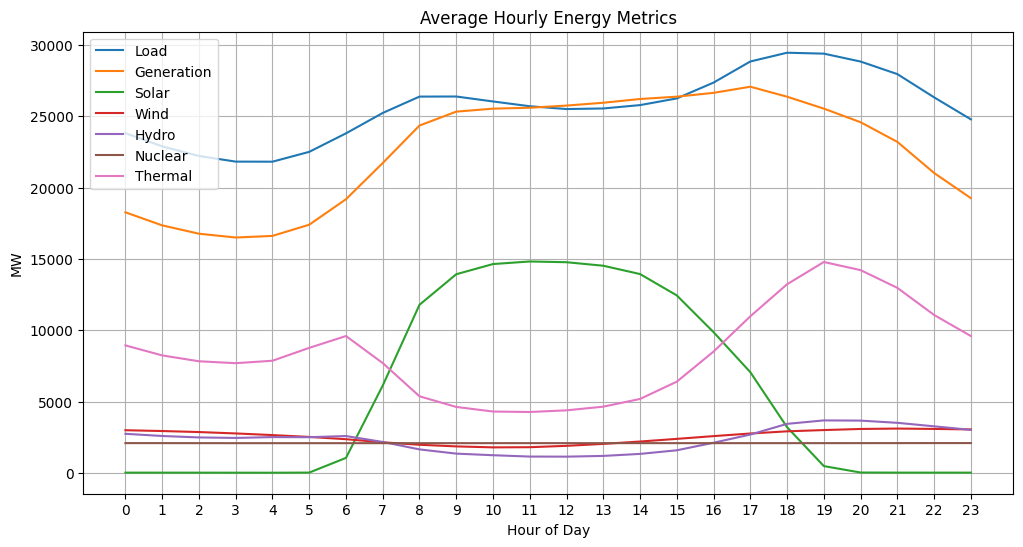

In [ ]:


plt.figure(figsize=(12, 6))
plt.plot(hourly_avg['Hour'], hourly_avg['Load'], label='Load')
plt.plot(hourly_avg['Hour'], hourly_avg['Generation'], label='Generation')
plt.plot(hourly_avg['Hour'], hourly_avg['Solar'], label='Solar')
plt.plot(hourly_avg['Hour'], hourly_avg['Wind'], label='Wind')
plt.plot(hourly_avg['Hour'], hourly_avg['Large Hydro'], label='Hydro')
plt.plot(hourly_avg['Hour'], hourly_avg['Nuclear'], label='Nuclear')
# thermal
plt.plot(hourly_avg['Hour'], hourly_avg['Thermal'], label='Thermal')

plt.xlabel('Hour of Day')
plt.ylabel('MW')
plt.title('Average Hourly Energy Metrics')
plt.grid(True)
plt.legend()
plt.xticks(range(0, 24))
plt.show()

In [15]:
# Lets do the same for monthly averages
caiso['Month'] = caiso['Date'].dt.month
monthly_avg = caiso.groupby('Month').mean(numeric_only=True).reset_index()
monthly_avg

,Month,Hour,Interval,Load,Solar,Wind,Net Load,Renewables,Nuclear,Large Hydro,Imports,Generation,Thermal,Load Less (Generation+Imports)
0,1,11.500000,6.5,23577.472973,3106.706480,1998.721782,18472.044711,6534.727744,2261.406645,1755.295706,1633.726206,21943.233025,11391.802930,5.137419e-01
1,2,11.500000,6.5,22970.769000,3886.992854,2101.790726,16981.985420,7458.442041,2259.615559,2189.365874,3103.344004,19867.090596,7959.667121,3.343996e-01
2,3,11.512786,6.5,21713.127246,4688.403051,2827.099440,14197.624754,8973.993739,2265.158453,2778.334734,2535.240538,19177.877360,5160.390434,9.347695e-03
3,4,11.500000,6.5,21670.267852,6282.799841,2891.590156,12495.877856,10533.531866,1356.992299,2838.195230,2181.525160,19488.746877,4760.027481,-4.184397e-03
4,5,11.500000,6.5,23014.365234,7477.455763,3680.226537,11856.682934,12671.834641,1405.308455,3219.226983,1552.834888,21461.530974,4165.160895,-6.285012e-04
5,6,11.500000,6.5,27101.660438,8188.649626,3486.571528,15426.439283,13258.468712,2271.165947,2755.865132,2492.805801,24608.855246,6323.355455,-6.086388e-04
6,7,11.500000,6.5,32201.237408,7700.039645,2576.844630,21924.353134,11827.822210,2265.464609,2927.627097,2346.538620,29854.698697,12833.784781,9.065289e-05
7,8,11.500000,6.5,30888.399790,7576.552378,2687.729888,20624.117524,11795.826407,2223.267213,2941.368783,3078.239867,27810.160178,10849.697776,-2.546542e-04
8,9,11.500000,6.5,28950.381343,6952.256744,2235.188317,19762.936283,10691.890892,2110.153875,2425.561135,3598.689272,25351.692071,10124.086169,4.611049e-07
9,10,11.500000,6.5,26456.646977,5657.683839,2032.442859,18766.520278,9066.582384,2194.901170,1412.075234,3619.275321,22837.372076,10163.813289,-4.203132e-04


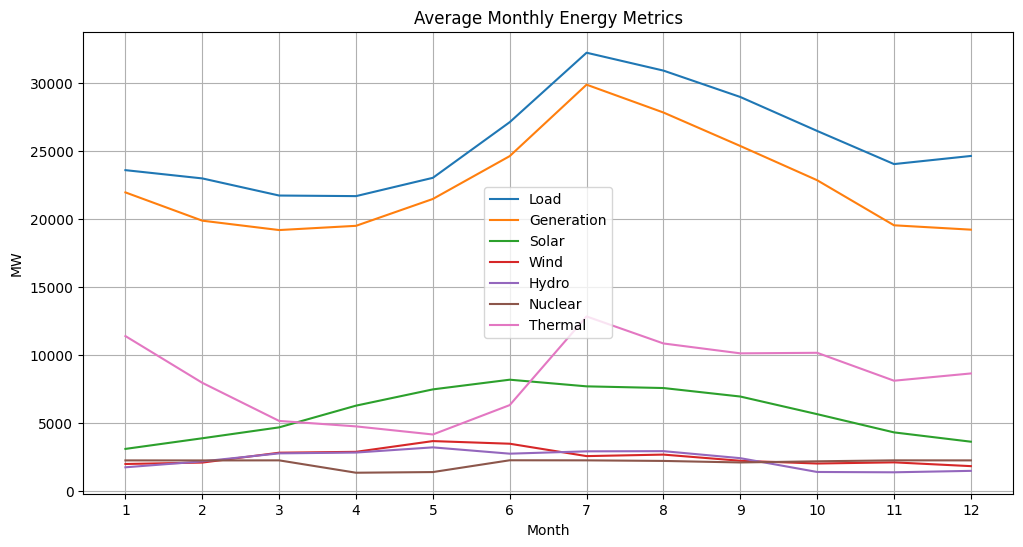

In [16]:
#plot monthly averages
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['Month'], monthly_avg['Load'], label='Load')
plt.plot(monthly_avg['Month'], monthly_avg['Generation'], label='Generation')
plt.plot(monthly_avg['Month'], monthly_avg['Solar'], label='Solar')
plt.plot(monthly_avg['Month'], monthly_avg['Wind'], label='Wind')
plt.plot(monthly_avg['Month'], monthly_avg['Large Hydro'], label='Hydro')
plt.plot(monthly_avg['Month'], monthly_avg['Nuclear'], label='Nuclear')
# thermal
plt.plot(monthly_avg['Month'], monthly_avg['Thermal'], label='Thermal')     
plt.xlabel('Month')
plt.ylabel('MW')
plt.title('Average Monthly Energy Metrics')
plt.grid(True)
plt.legend()
plt.xticks(range(1, 13))
plt.show()

In [19]:
CAISO_curtailments=pd.read_excel("production-and-curtailments-data-2024.xlsx", sheet_name="Curtailments")
CAISO_curtailments['Date'] = pd.to_datetime(CAISO_curtailments['Date'])
#CAISO_curtailments['Hour'] = CAISO_curtailments['Date'].dt.hour
CAISO_curtailments

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Reason
0,2024-01-01 08:00:00,11,11,NaN,30.585320,Local
1,2024-01-01 08:00:00,12,12,NaN,5.155795,Local
2,2024-01-01 08:00:00,13,1,NaN,4.256309,Local
3,2024-01-01 08:00:00,13,2,NaN,14.668363,Local
4,2024-01-01 08:00:00,13,3,NaN,4.790443,Local
...,...,...,...,...,...,...
51852,2024-12-31 08:00:00,16,2,NaN,15.039996,Local
51853,2024-12-31 08:00:00,16,2,NaN,10.360001,System
51854,2024-12-31 08:00:00,16,3,NaN,16.239996,System
51855,2024-12-31 08:00:00,16,4,NaN,8.629999,System


In [20]:
# make an hourly average of curtailments
curtailments_hourly_avg = CAISO_curtailments.groupby('Hour').mean(numeric_only=True).reset_index()
curtailments_hourly_avg

,Hour,Interval,Wind Curtailment,Solar Curtailment
0,1,6.333333,72.767956,NaN
1,2,6.587571,93.762332,NaN
2,3,6.541935,104.076363,NaN
3,4,6.493243,89.725266,NaN
4,5,6.442623,84.989081,NaN
5,6,6.432432,73.924484,4.584774
6,7,8.569307,79.227338,115.342386
7,8,7.733025,110.485337,343.050682
8,9,6.831992,105.397739,584.531186
9,10,6.557140,100.553286,793.868142


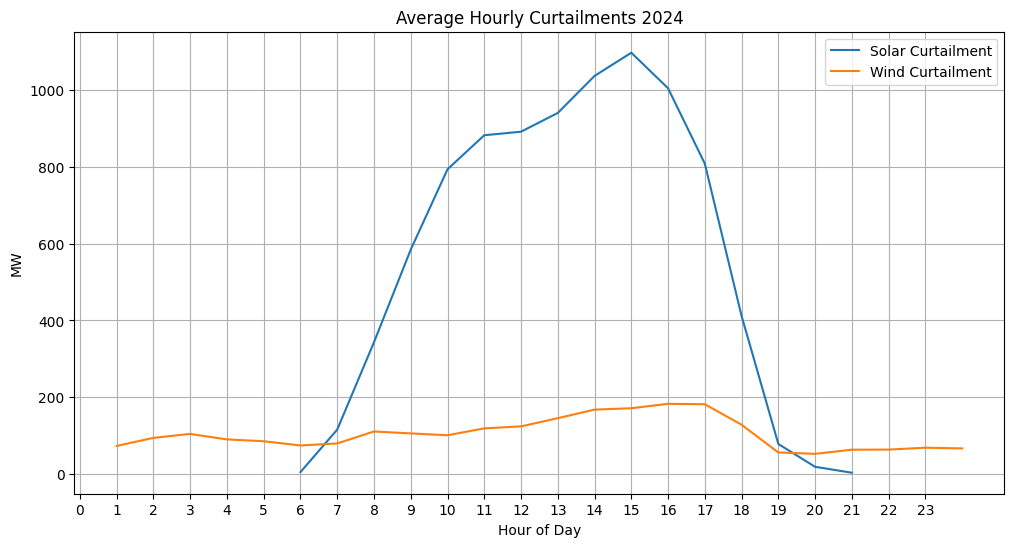

In [25]:
#Graph curtailments
plt.figure(figsize=(12, 6))
plt.plot(curtailments_hourly_avg['Hour'], curtailments_hourly_avg['Solar Curtailment'], label='Solar Curtailment')
plt.plot(curtailments_hourly_avg['Hour'], curtailments_hourly_avg['Wind Curtailment'], label='Wind Curtailment')

plt.xlabel('Hour of Day')
plt.ylabel('MW')
plt.title('Average Hourly Curtailments 2024')
plt.grid(True)
plt.legend()
plt.xticks(range(0, 24))
plt.show()

In [26]:
# Lets do the same for monthly averages of curtailments
CAISO_curtailments['Month'] = CAISO_curtailments['Date'].dt.month
curtailments_monthly_avg = CAISO_curtailments.groupby('Month').mean(numeric_only=True).reset_index()
curtailments_monthly_avg

,Month,Hour,Interval,Wind Curtailment,Solar Curtailment
0,1,12.847008,6.533301,82.112025,600.345170
1,2,12.659891,6.473321,107.804684,977.692113
2,3,13.222981,6.473982,212.407202,2076.603208
3,4,13.160583,6.465923,138.347949,1947.440754
4,5,13.345835,6.467239,188.561583,1287.852055
5,6,13.752419,6.497581,107.340031,402.392130
6,7,13.761659,6.488462,43.526604,125.398461
7,8,13.853806,6.494966,14.386948,178.849015
8,9,13.622828,6.449037,38.333757,345.556301
9,10,13.235210,6.510180,105.551279,474.323270


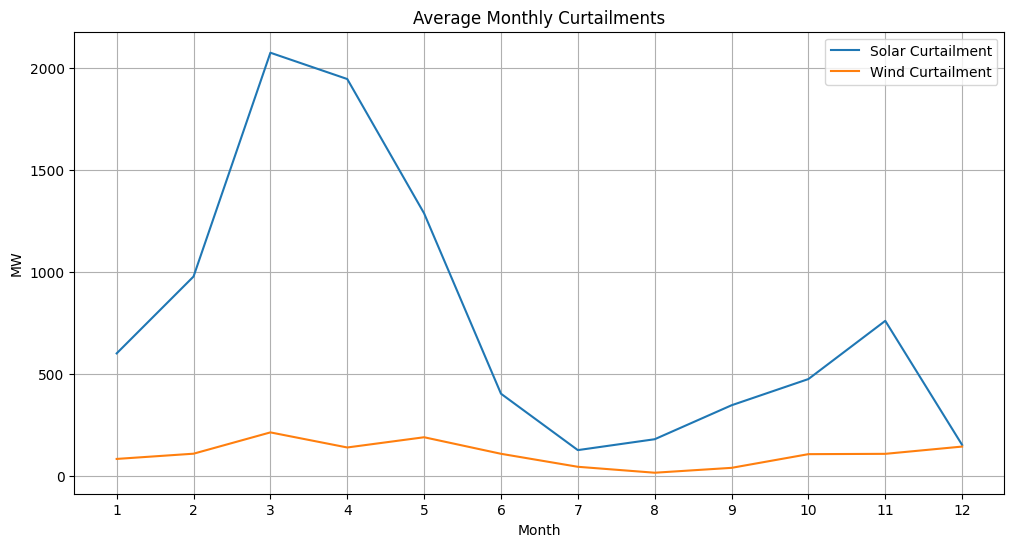

In [ ]:
#Plot monthly curtailments
plt.figure(figsize=(12, 6))
plt.plot(curtailments_monthly_avg['Month'], curtailments_monthly_avg['Solar Curtailment'], label='Solar Curtailment')
plt.plot(curtailments_monthly_avg['Month'], curtailments_monthly_avg['Wind Curtailment'], label='Wind Curtailment')

plt.xlabel('Month')
plt.ylabel('MW')
plt.title('Average Monthly Curtailments 2024')
plt.grid(True)
plt.legend()
plt.xticks(range(1, 13))
plt.show()